# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1579,28,67,"(0.31, 1.8)","(0.186, 1.825, -0.115, -0.994)",1,1.0,"(0.223, 2.011, -0.134, -1.101)",1.0,1.0,"(0.263, 2.198, -0.156, -1.209)"
2077,24,88,"(0.65, 0.8)","(0.132, 0.787, -0.103, -0.843)",1,1.0,"(0.148, 0.984, -0.12, -1.179)",0.0,1.0,"(0.167, 0.79, -0.143, -0.917)"
774,2,34,"(0.58, 0.1)","(-0.042, 0.611, -0.071, -4.616)",1,1.0,"(-0.03, 0.9, -0.164, -7.014)",0.0,1.0,"(-0.012, 0.627, -0.304, -5.128)"
552,9,26,"(0.23, 1.9)","(-0.065, -0.954, -0.015, 0.418)",1,1.0,"(-0.084, -0.768, -0.006, 0.332)",0.0,1.0,"(-0.099, -0.954, 0.0, 0.416)"
1198,51,50,"(0.69, 1.4)","(0.409, 0.594, -0.115, -0.282)",0,1.0,"(0.42, 0.405, -0.121, -0.124)",1.0,1.0,"(0.429, 0.596, -0.123, -0.328)"
...,...,...,...,...,...,...,...,...,...,...
1352,37,57,"(0.14, 1.7)","(-0.26, -2.424, 0.184, 1.266)",1,1.0,"(-0.309, -2.239, 0.209, 1.196)",1.0,1.0,"(-0.354, -2.054, 0.233, 1.129)"
912,29,39,"(0.23, 1.5)","(0.064, 0.197, -0.112, -0.275)",0,1.0,"(0.068, 0.011, -0.118, -0.181)",1.0,1.0,"(0.068, 0.198, -0.122, -0.301)"
481,18,23,"(0.6, 1.5)","(0.037, 0.021, -0.083, -0.197)",1,1.0,"(0.037, 0.211, -0.087, -0.363)",0.0,1.0,"(0.041, 0.023, -0.094, -0.225)"
520,11,24,"(0.68, 1.3)","(-0.069, -0.203, 0.062, 0.261)",1,1.0,"(-0.073, -0.013, 0.068, 0.08)",1.0,1.0,"(-0.073, 0.177, 0.069, -0.101)"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.1641721874475479, 0.503868818283081, 0.1218...",2.102258,1.517695
1,1,"[0.1602882295846939, 0.5001004338264465, 0.118...",2.079186,1.502660
2,2,"[0.1564580351114273, 0.49636781215667725, 0.11...",2.056402,1.487794
3,3,"[0.15268050134181976, 0.49266746640205383, 0.1...",2.033893,1.473094
4,4,"[0.14895813167095184, 0.48900312185287476, 0.1...",2.011657,1.458587


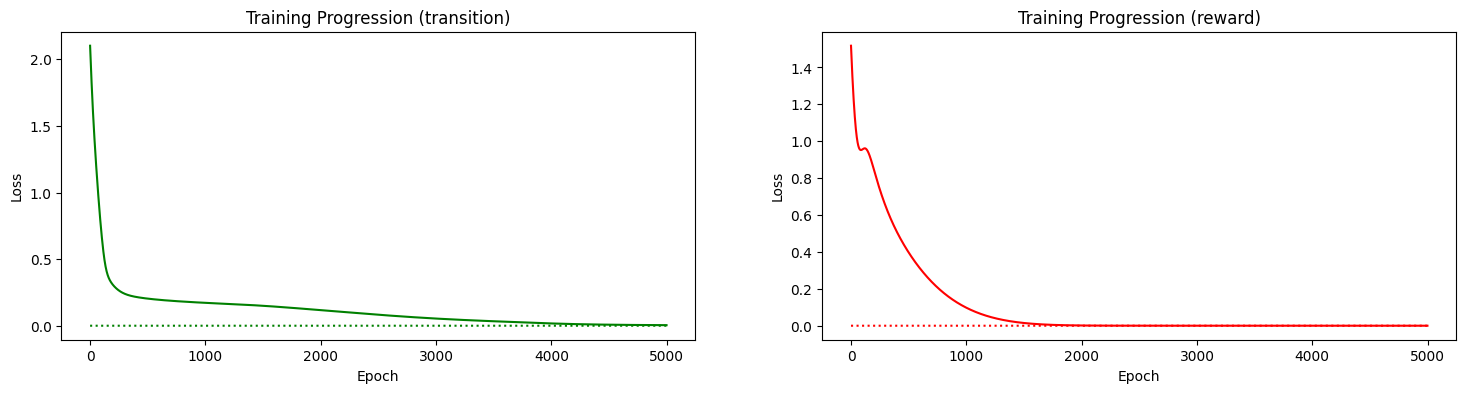

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

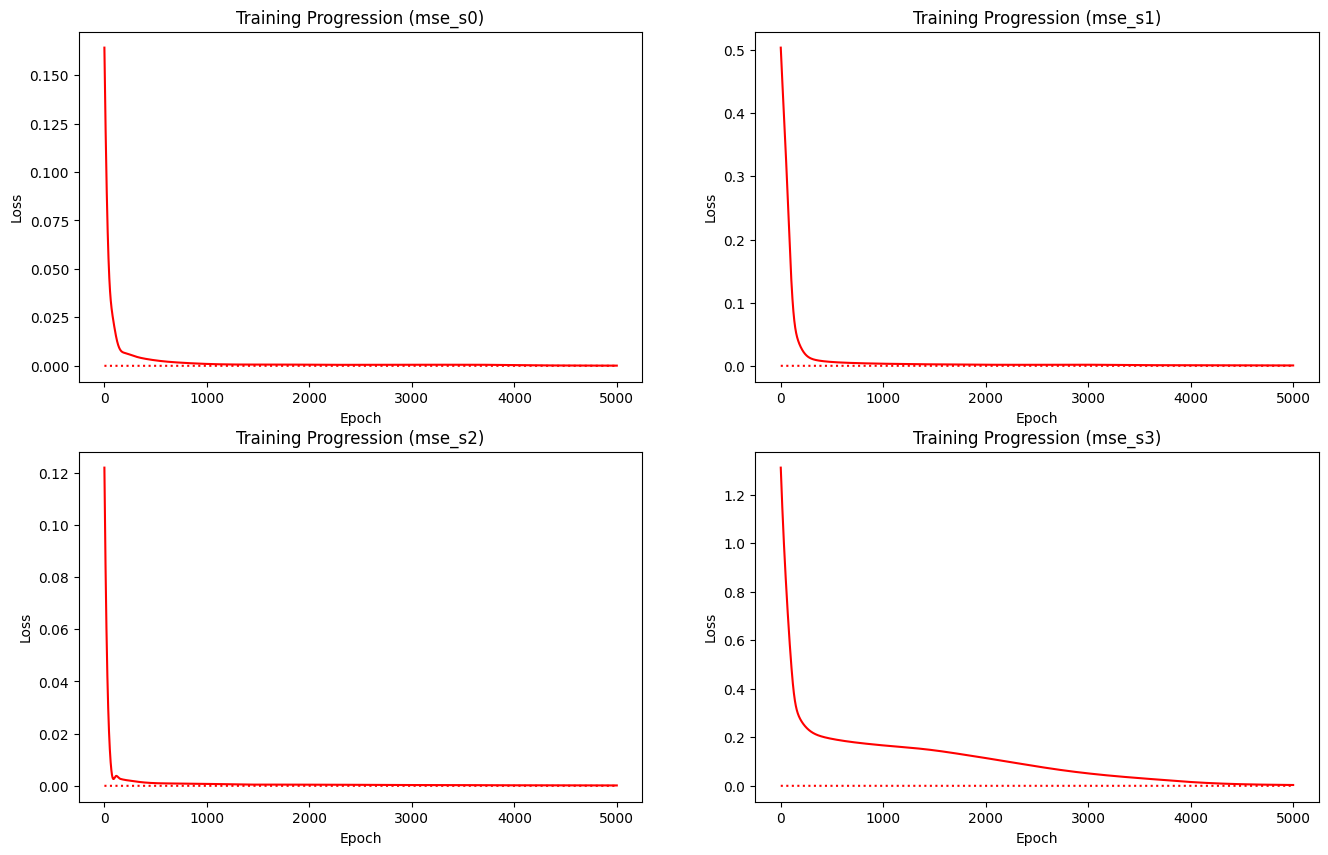

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [6]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s3,estimated_s0,estimated_s1,estimated_s2,estimated_s3,rse_s0,rse_s1,rse_s2,rse_s3,rse_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)",...,-0.018,-0.006,-0.050,-0.019,-0.014,0.004,0.008,0.003,0.004,0.0
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)",...,-0.218,-0.008,0.138,-0.024,-0.215,0.003,0.011,0.008,0.003,0.0
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)",...,-0.418,-0.004,0.330,-0.024,-0.408,0.004,0.010,0.003,0.010,0.0
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)",...,-0.619,0.003,0.525,-0.029,-0.602,0.004,0.006,0.000,0.017,0.0
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)",...,-0.822,0.014,0.719,-0.038,-0.798,0.005,0.003,0.003,0.024,0.0


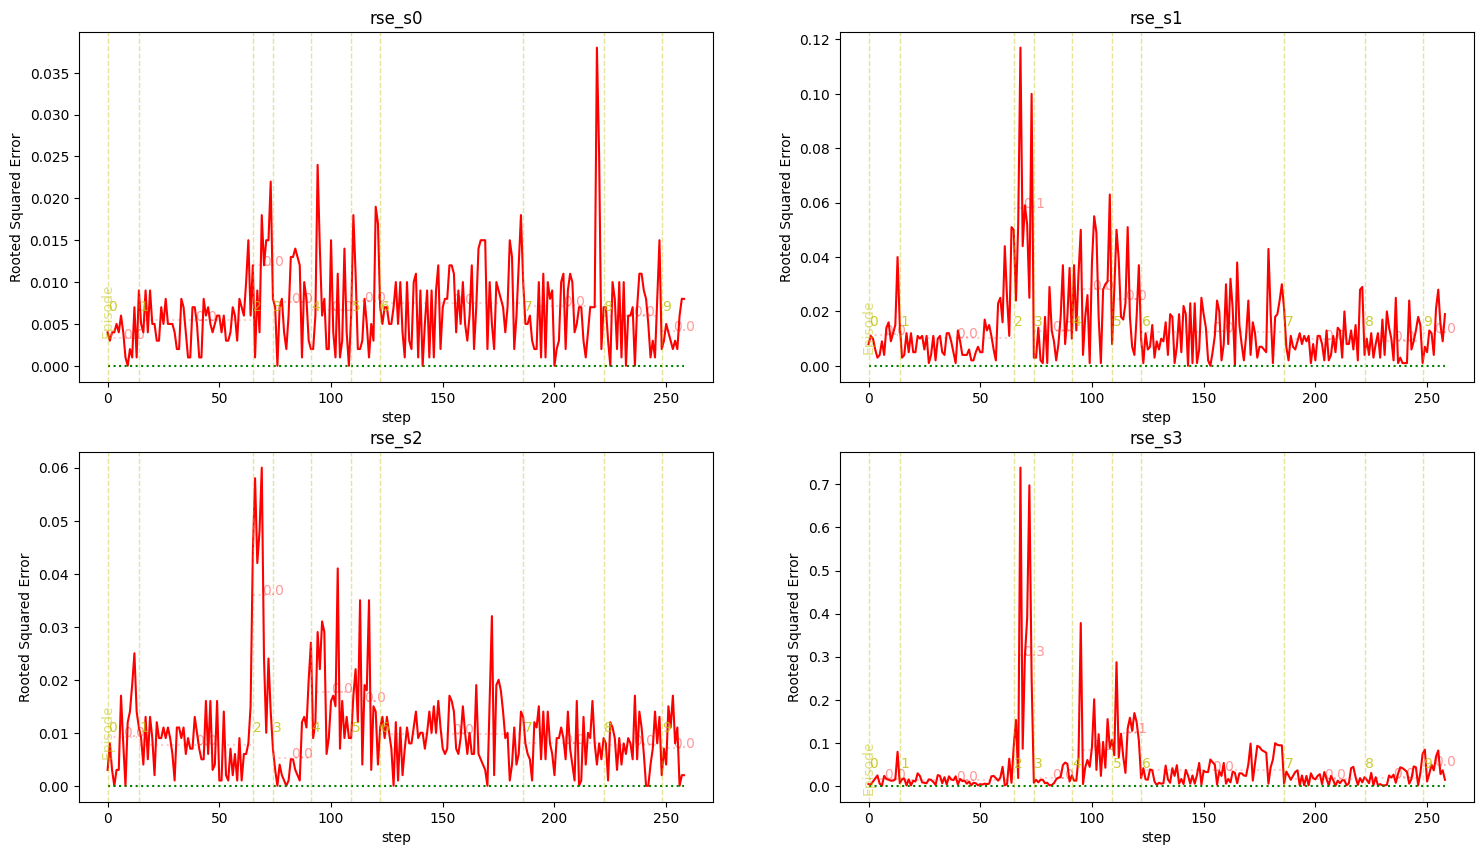

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

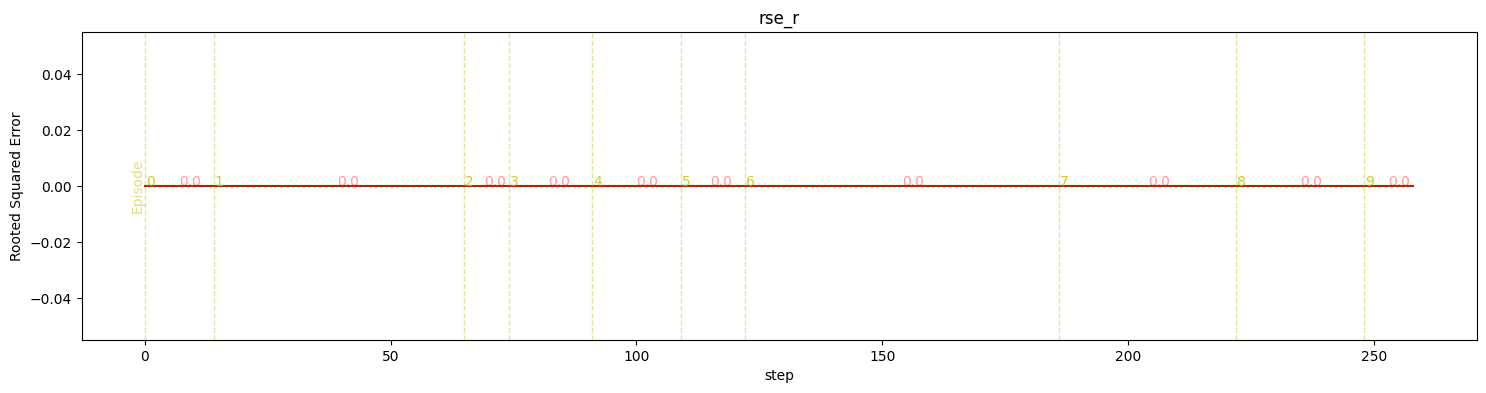

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

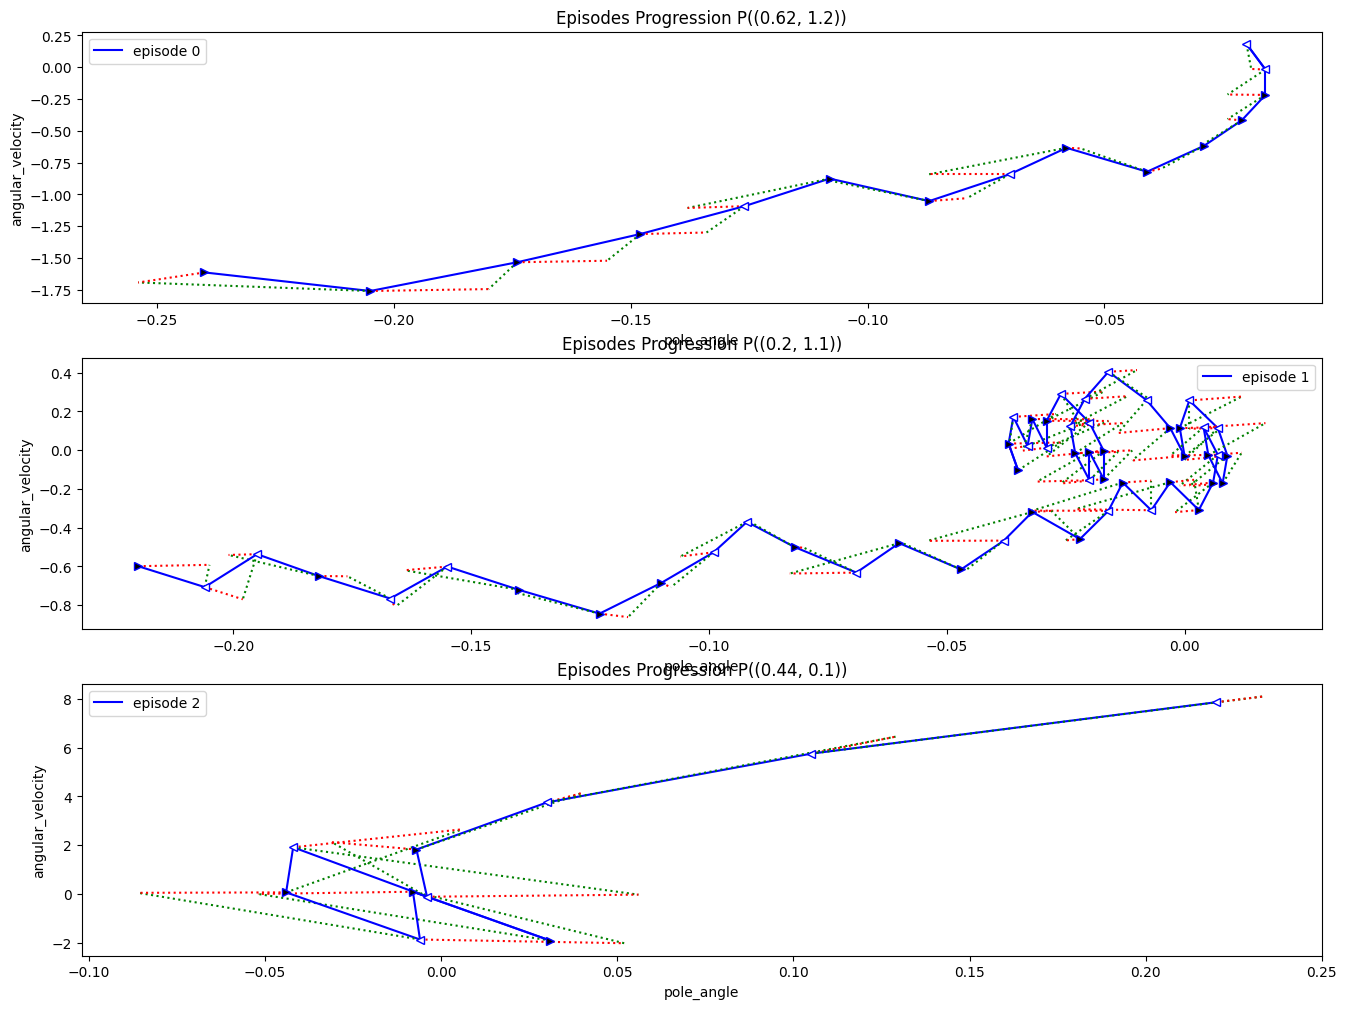

In [9]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()